In [1]:
import ROOT as rt
import sys
import collections
from collections import OrderedDict
import uproot

import os
import scipy
import awkward as ak
import time
import subprocess

GIT_REPO = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'], stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8')
sys.path.append(GIT_REPO + '/lib/')
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
from helper_functions import *

import numpy as np
from scipy.stats import norm
import math
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()
CMS_lumi.writeExtraText = 0


print(sys.version)

Welcome to JupyROOT 6.24/06
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


# Load ntuples

In [2]:
%%time

fpath =OrderedDict()
tree = OrderedDict()
LUMI_SCALE = 1

start_t = time.time()
version = "v39"
# for data_year in ['2022','2023','all']:
for data_year in ['all']:

    # path = "/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/data/raw/"
    # fpath_bkg[data_year] = path + f"data_{data_year}_goodLumi.root"
    if data_year == 'all':path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/{version}/normalized/'
    else: path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data{data_year}/{version}/normalized/'
    if data_year == '2022':fpath['data'+data_year] = path + "DisplacedJet-EXOCSCCluster_Run2022-PromptReco_goodLumi.root"
    elif data_year == '2023':fpath['data'+data_year] = path + "Muon-EXOCSCCluster_Run2023-PromptReco_goodLumi.root"
    elif data_year == 'all':fpath['data'+data_year] = path + "EXOCSCCluster_Run2022_2024_goodLumi.root"

fpath['sig'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root'
NEvents = {}

for k,v in fpath.items():
    print (k, v)
    root_dir = uproot.open(v) 

    tree[k] = root_dir['MuonSystem']
    NEvents[k] = root_dir['NEvents'].values()[0]
    # NEvents[k] = root_dir['NEvents'].counts()
    print("NEvents",NEvents[k])


dataall /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/v39/normalized/EXOCSCCluster_Run2022_2024_goodLumi.root
NEvents 182909920.0
sig /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v39/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root
NEvents 189759580.0
CPU times: user 549 ms, sys: 19.2 ms, total: 568 ms
Wall time: 861 ms


In [3]:
categories = ['lowMET','highMET']
# categories = ['inclusive']
MET_THRESHOLD = 50


# apply selections

In [14]:
%%time

cscRechitClusterPhi = {}
dtRechitClusterPhi = {}
deltaPhi_cluster  = {}
cscRechitClusterDNN  = {}
dtRechitClusterSize  = {}
dtRechitClusterBX  = {}
cscRechitClusterSize = {}
weight = {}
HMTEff = {}

cscRechitClusterEta = {}
cscRechitClusterPhi = {}
dtRechitClusterEta = {}
dtRechitClusterPhi  = {}
dtRechitClusterMet_dPhi = {}
cscRechitClusterMet_dPhi = {}

cscRechitClusterNStation = {}
cscRechitClusterAvgStation = {}
cscRechitClusterMaxStation = {}

dtRechitClusterNStation = {}
dtRechitClusterAvgStation = {}
dtRechitClusterMaxStation = {}
cscRechitClusterTimeSpread = {}
            
evtNum = {}
runNum = {}
met = {}
Puppimet = {}
# categories = ['NStation1', 'NStation2']
# categories = ['inclusive']
region_list = [ 'oot', 'signal']
for region in region_list:
    for tree_k in tree.keys():
        T = tree[tree_k]
        
        for cat in categories:
            # if not (met_cat == 'highMET'):continue
            k = f'{region}_{tree_k}_{cat}'
            ########### SELECTION: CLUSTERS ############
            me1 = (T['cscRechitClusterNRechitChamberPlus11'].array()+ T['cscRechitClusterNRechitChamberPlus12'].array()+\
            T['cscRechitClusterNRechitChamberMinus11'].array()+ T['cscRechitClusterNRechitChamberMinus12'].array())
            cscRechitClusterR = (T['cscRechitClusterX'].array()**2+T['cscRechitClusterY'].array()**2)**0.5

            #one cluster to pass trigger
            csccluster = np.logical_and(T['cscRechitClusterTimeWeighted'].array() < 12.5, T['cscRechitClusterTimeWeighted'].array() > -5)
            csccluster = csccluster & (me1 ==0)
            csccluster = csccluster & (T['cscRechitClusterTimeSpreadWeightedAll'].array()<25)
            csccluster = csccluster & (np.abs(T['cscRechitClusterEta'].array())<1.9)
            csccluster = csccluster & (T['cscRechitClusterJetVetoPt'].array()<30)
            csccluster = csccluster & np.logical_not((T['cscRechitClusterMuonVetoPt'].array() > 30) & T['cscRechitClusterMuonVetoGlobal'].array())    


            dtcluster = (T['dtRechitClusterNHitStation1'].array()>=0)
            dtcluster = dtcluster & (T['dtRechitCluster_match_RPChits_dPhi0p5'].array() >= 1)
            dtcluster = dtcluster & (T['dtRechitClusterJetVetoPt'].array()<30)
            dtcluster = dtcluster & np.logical_not((T['dtRechitClusterMuonVetoPt'].array() > 30) & T['dtRechitClusterMuonVetoLooseId'].array())
            
            ###cosmic veto for DT clusters###
            
            sel_cosmic = np.logical_and(T['dtRechitClusterNOppositeSegStation1'].array()>0, T['dtRechitClusterNOppositeSegStation2'].array()>0)
            sel_cosmic = np.logical_and(sel_cosmic, T['dtRechitClusterNOppositeSegStation3'].array()>0)
            sel_cosmic = np.logical_and(sel_cosmic, T['dtRechitClusterNOppositeSegStation4'].array()>0)
            sel_cosmic = np.logical_and(sel_cosmic, T['dtRechitClusterNOppositeSegStation1'].array()+T['dtRechitClusterNOppositeSegStation2'].array()+\
                                       T['dtRechitClusterNOppositeSegStation3'].array()+T['dtRechitClusterNOppositeSegStation4'].array()>=6)
            nstation = (T['dtRechitClusterNSegStation1'].array()>1)*1+(T['dtRechitClusterNSegStation2'].array()>1)*1\
            +(T['dtRechitClusterNSegStation3'].array()>1)*1+(T['dtRechitClusterNSegStation4'].array()>1)*1
            dtcluster = dtcluster & np.logical_not(np.logical_and(nstation>=3, sel_cosmic))
            

        ########### SELECTION: EVENTS ############
            sel_ev = (T['nCscRechitClusters_nocut'].array()==1) & (T['nDtRechitClusters_nocut'].array()==1)
            if "data" in k: sel_ev = sel_ev & T['HLT_CSCCSC'].array() 
            
            sel_ev = np.logical_and(sel_ev ,T['Puppimet'].array() < 200)
            if 'Nst1' in cat:csccluster = csccluster & (T['cscRechitClusterNStation10'].array() == 1)
            elif 'Nst2' in cat:csccluster = csccluster & (T['cscRechitClusterNStation10'].array() > 1)
            
            if 'lowMET' in cat:sel_ev = np.logical_and(sel_ev ,T['Puppimet'].array() < MET_THRESHOLD)
            if 'highMET' in cat: sel_ev = np.logical_and(sel_ev ,T['Puppimet'].array() > MET_THRESHOLD)
            
            cluster_pass_HLT = HLT_CSC(T['cscRechitClusterEta'].array(),T['cscRechitClusterNStation10'].array(),T['cscRechitClusterSize'].array())
            sel_ev  = np.logical_and(sel_ev,np.sum(cluster_pass_HLT, axis = 1) >= 1) # at least one passes HLT
            
            sel_ev = np.logical_and(sel_ev ,T['Flag_all'].array())
            sel_ev = np.logical_and(sel_ev ,T['nCscRings'].array()+T['nDtRings'].array()<10)
            print(k, np.count_nonzero(T['jetVeto'].array()&T['Flag_ecalBadCalibFilter'].array()&sel_ev)/np.count_nonzero(sel_ev))

            sel_ev = np.logical_and(sel_ev ,T['jetVeto'].array())
            sel_ev = np.logical_and(sel_ev ,T['Flag_ecalBadCalibFilter'].array())
            
            sel_ev  = sel_ev & (np.sum(dtcluster, axis = 1) == 1)
            sel_ev  = sel_ev & (np.sum(csccluster, axis = 1) == 1)
        ########### BRANCHES ############

           ##### event variables ##### 
            # make sure cluster0 and cluster1 index are different

            cscRechitClusterPhi[k] = T['cscRechitClusterPhi'].array()[csccluster][sel_ev][:,0]
            dtRechitClusterPhi[k] = T['dtRechitClusterPhi'].array()[dtcluster][sel_ev][:,0]
            deltaPhi_cluster[k] = deltaPhi(np.array(cscRechitClusterPhi[k]), np.array(dtRechitClusterPhi[k]))

            cscRechitClusterDNN[k] = T['cscRechitClusterDNN_bkgMC_plusBeamHalo'].array()[csccluster][sel_ev][:,0]
            dtRechitClusterBX[k] = T['dtRechitCluster_match_RPCBx_dPhi0p5'].array()[dtcluster][sel_ev][:,0]
            dtRechitClusterSize[k] = T['dtRechitClusterSize'].array()[dtcluster][sel_ev][:,0]
            # cscRechitClusterSize1[k] = T['cscRechitClusterSize'].array()[sel_ev][cluster1][:,0]

            if "lowMET" in cat: sel = (np.abs(deltaPhi_cluster[k])>1)
            else: sel = (np.abs(deltaPhi_cluster[k])>0.4)
            
            if 'oot' in region:sel = sel & (cscRechitClusterDNN[k] > 0.96) & (dtRechitClusterBX[k]<0)
            elif 'invertDNN' in region: sel = sel & (cscRechitClusterDNN[k] < 0.96) & (dtRechitClusterBX[k] == 0)
            elif 'signal' in region:sel = sel & (cscRechitClusterDNN[k] > 0.96) & (dtRechitClusterBX[k] == 0)
            else: assert(False)


            deltaPhi_cluster[k] = deltaPhi_cluster[k][sel]
            dtRechitClusterSize[k] = dtRechitClusterSize[k][sel]
            cscRechitClusterSize[k] = T['cscRechitClusterSize'].array()[csccluster][sel_ev][sel][:,0]
            HMTEff[k] = T['cscRechitClusterHMTEfficiency'].array()[csccluster][sel_ev][sel][:,0]
            if 'data' in k:weight[k] = (T['weight'].array())[sel_ev][sel]* 0.0 + 1
            else: weight[k] = (T['pileupWeight'].array()*T['weight'].array())[sel_ev][sel]*HMTEff[k]*LUMI_SCALE

            cscRechitClusterEta[k] = T['cscRechitClusterEta'].array()[csccluster][sel_ev][sel][:,0]
            cscRechitClusterPhi[k] = T['cscRechitClusterPhi'].array()[csccluster][sel_ev][sel][:,0]
            dtRechitClusterEta[k] = T['dtRechitClusterEta'].array()[dtcluster][sel_ev][sel][:,0]
            dtRechitClusterPhi[k] = T['dtRechitClusterPhi'].array()[dtcluster][sel_ev][sel][:,0]
            cscRechitClusterMet_dPhi[k] = T['cscRechitClusterMet_dPhi'].array()[csccluster][sel_ev][sel][:,0]
            dtRechitClusterMet_dPhi[k] = T['dtRechitClusterMet_dPhi'].array()[dtcluster][sel_ev][sel][:,0]
            
            cscRechitClusterNStation[k] = T['cscRechitClusterNStation10'].array()[csccluster][sel_ev][sel][:,0]
            cscRechitClusterAvgStation[k] = T['cscRechitClusterAvgStation10'].array()[csccluster][sel_ev][sel][:,0]
            cscRechitClusterMaxStation[k] = T['cscRechitClusterMaxStation'].array()[csccluster][sel_ev][sel][:,0]
            cscRechitClusterTimeSpread[k] = T['cscRechitClusterTimeSpreadWeightedAll'].array()[csccluster][sel_ev][sel][:,0]

            dtRechitClusterNStation[k] = T['dtRechitClusterNStation10'].array()[dtcluster][sel_ev][sel][:,0]
            dtRechitClusterAvgStation[k] = T['dtRechitClusterAvgStation10'].array()[dtcluster][sel_ev][sel][:,0]
            dtRechitClusterMaxStation[k] = T['dtRechitClusterMaxStation'].array()[dtcluster][sel_ev][sel][:,0]
            met[k] = T['met'].array()[sel_ev][sel]
            Puppimet[k] = T['Puppimet'].array()[sel_ev][sel]
            
            evtNum[k] = T['evtNum'].array()[sel_ev][sel]
            runNum[k] = T['runNum'].array()[sel_ev][sel]

            if np.count_nonzero(sel)<=1:continue
            print("correlation between two variables:", k, scipy.stats.pearsonr(deltaPhi_cluster[k], dtRechitClusterSize[k]))
            print("events in this region:", k, len(deltaPhi_cluster[k]))

oot_dataall_lowMET 0.9594688351656955
correlation between two variables: oot_dataall_lowMET (-0.004505932209970223, 0.308411827348316)
events in this region: oot_dataall_lowMET 51100
oot_dataall_highMET 0.9230039991714863
correlation between two variables: oot_dataall_highMET (0.001025205229772171, 0.9296889523430504)
events in this region: oot_dataall_highMET 7410
oot_sig_lowMET 0.9621894486786103
correlation between two variables: oot_sig_lowMET (0.04121381012478687, 0.7097222341846186)
events in this region: oot_sig_lowMET 84
oot_sig_highMET 0.9399751707014277
correlation between two variables: oot_sig_highMET (0.05896480974315119, 0.6489386923492324)
events in this region: oot_sig_highMET 62
signal_dataall_lowMET 0.9594688351656955
correlation between two variables: signal_dataall_lowMET (-0.0006305547666827838, 0.8939619487458977)
events in this region: signal_dataall_lowMET 44688
signal_dataall_highMET 0.9230039991714863
correlation between two variables: signal_dataall_highMET (

In [8]:
for k in runNum.keys():
    cond = cscRechitClusterTimeSpread[k]<25
    if "lowMET" in k: cond = cond & (cscRechitClusterSize[k]>160)
    else: cond = cond & (cscRechitClusterSize[k]>120)
    print(k, np.count_nonzero(cond))

oot_dataall_lowMET 40059
oot_dataall_highMET 6720
oot_sig_lowMET 59
oot_sig_highMET 56
signal_dataall_lowMET 35075
signal_dataall_highMET 6680
signal_sig_lowMET 13194
signal_sig_highMET 6773


oot_dataall_lowMET 48240.0
oot_dataall_lowMET 1.0 50147
oot_dataall_highMET 7061.0
oot_dataall_highMET 0.9999999999999999 7315
signal_dataall_lowMET 41727.0
signal_dataall_lowMET 1.0 43782
signal_dataall_highMET 6963.0
signal_dataall_highMET 0.9999999999999998 7274
signal_sig_lowMET 12207.750930786133
signal_sig_lowMET 1.0000000000000002 19651
signal_sig_highMET 5981.401390075684
signal_sig_highMET 0.9999999999999997 9463
0.09026074409484863


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/cscRechitClusterSize_dtcsc.png has been created
Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/cscRechitClusterSize_dtcsc.pdf has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/cscRechitClusterSize_dtcsc.C has been genera

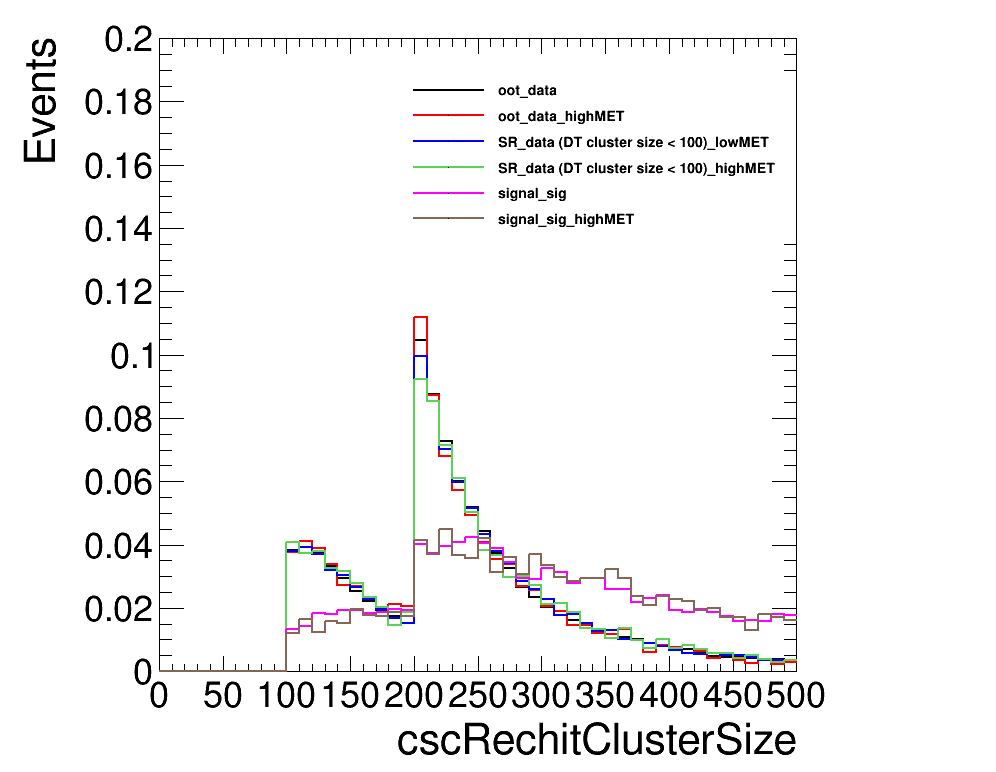

In [13]:
start_t = time.time()
c = rt.TCanvas('c','c', 1000, 800)
h = {}
leg = rt.TLegend(0.4,0.7,0.8,0.9)
leg.SetBorderSize(0)
plot_var = [ met, Puppimet, dtRechitClusterNStation, cscRechitClusterNStation, dtRechitClusterAvgStation, cscRechitClusterAvgStation,\
            dtRechitClusterMaxStation, cscRechitClusterMaxStation, dtRechitClusterPhi, dtRechitClusterEta, cscRechitClusterEta, cscRechitClusterPhi, cscRechitClusterSize]
axis = [ 'met','Puppimet', 'dtRechitClusterNStation', 'cscRechitClusterNStation', 'dtRechitClusterAvgStation', 'cscRechitClusterAvgStation',\
            'dtRechitClusterMaxStation', 'cscRechitClusterMaxStation', 'dtRechitClusterPhi','dtRechitClusterEta','cscRechitClusterEta', 'cscRechitClusterPhi','cscRechitClusterSize']
name = [ 'met', 'Puppimet','dtRechitClusterNStation', 'cscRechitClusterNStation', 'dtRechitClusterAvgStation', 'cscRechitClusterAvgStation',\
            'dtRechitClusterMaxStation', 'cscRechitClusterMaxStation', 'dtRechitClusterPhi','dtRechitClusterEta','cscRechitClusterEta','cscRechitClusterPhi','cscRechitClusterSize']

bins = [[50,0,300], [50,0,300],[5,0,5],[5,0,5], [50,0,5], [50,0,5], [5,0,5],[5,0,5], [50,0,4], [50,0,1.2], [50,0,2.4], [50,0,3.5],[50,0,500]]

plot_index = -1
i = 0
for k in plot_var[plot_index].keys():

    # if 'signal_dataall' in k:continue
    # if not "OOT" in k and  not "signal" in k:continue
    if 'invertDNN_sig' in k or 'oot_sig' in k:continue
    cond = cscRechitClusterSize[k]>0
    # cond = cond & (np.abs(deltaPhi_cluster[k])>2.8)
    if 'signal_dataall' in k: cond & dtRechitClusterSize[k] < 100
    h[k] = create_TH1D( np.abs(np.array(plot_var[plot_index][k][cond])), axis_title = [axis[plot_index],'Events'], binning=bins[plot_index], weights = np.array(weight[k][cond]))
    # h[k] = create_TH1D( np.array((met[k]-Puppimet[k])[cond]), axis_title = ["met-Puppi met",'Events'], binning=[100,-100,150], weights = np.array(weight[k][cond]))
    print(k, h[k].Integral())
    
    if h[k].Integral()>0:h[k].Scale(1./h[k].Integral())
    h[k].SetLineColor(std_color_list[i])
    h[k].SetMaximum(0.2)
    # if plot_index >= 6:h[k].SetMaximum(0.2)
    if "signal_data" in k:leg.AddEntry(h[k],'SR_data (DT cluster size < 100)_' + k.split('_')[-1])
    else:     leg.AddEntry(h[k],k.replace('all','').replace('_lowMET',''))

    
    h[k].Draw('hist same')
    i+=1

    print(k, h[k].Integral(), len(dtRechitClusterSize[k]))
    
leg.Draw()
# if plot_index == 0 or plot_index == 3 or plot_index == 8:c.SetLogy()
c.SetRightMargin(0.2)
# c.SetLogy()
c.Draw()

c.SaveAs(GIT_REPO + "/plots/ABCD/"+name[plot_index]+"_dtcsc.png")
c.SaveAs(GIT_REPO + "/plots/ABCD/"+name[plot_index]+"_dtcsc.pdf")
c.SaveAs(GIT_REPO + "/plots/ABCD/"+name[plot_index]+"_dtcsc.C")


print(time.time()-start_t)

oot_dataall_lowMET 17921.0
oot_dataall_highMET 4387.0
oot_dataall_highMET 7300.0 7302
oot_sig_lowMET 14.103013
oot_sig_highMET 31.160164
signal_dataall_lowMET 15852.0
signal_dataall_highMET 4385.0
signal_sig_lowMET 3528.0703
signal_sig_highMET 3972.3413
0.023629426956176758


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


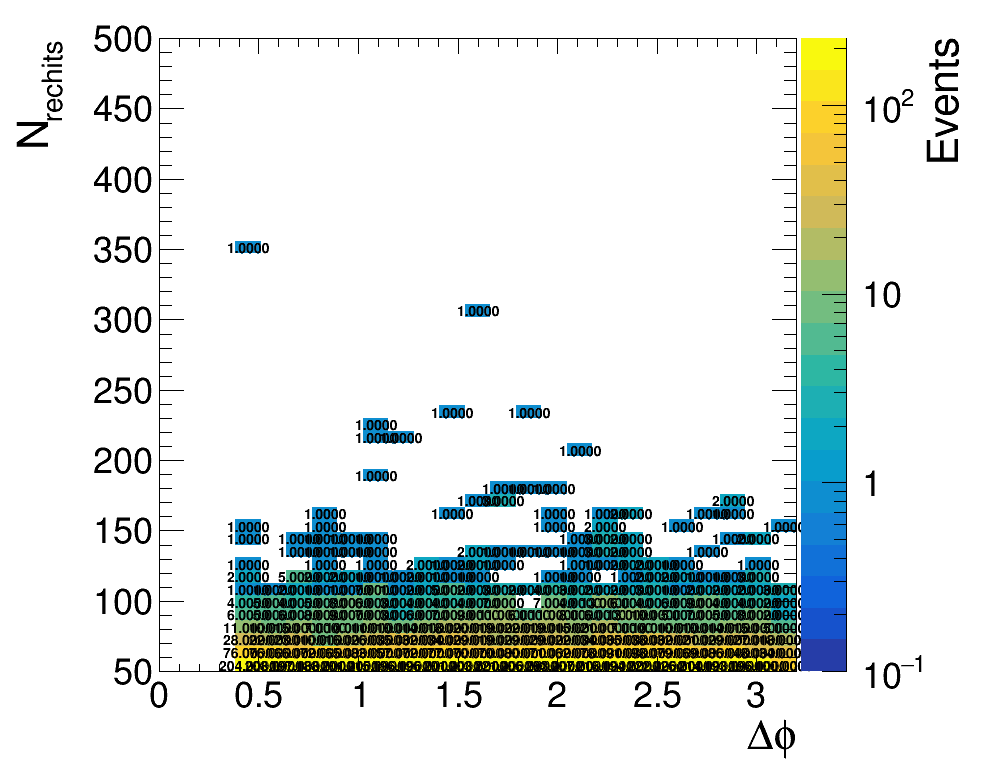

In [10]:
start_t = time.time()
c = rt.TCanvas('c','c', 1000, 800)

for k in dtRechitClusterSize.keys():
    print(k, np.sum(weight[k][met[k]>50]))
    # if not k == "oot_dataall_lowMET":continue
    if not k == "oot_dataall_highMET":continue
    cond = (np.abs(dtRechitClusterMaxStation[k])>0)
    h = create_TH2D(np.column_stack(( np.abs(deltaPhi_cluster[k]), np.array(dtRechitClusterSize[k]), )),
                   axis_title = ['#Delta#phi','N_{rechits}','Events'], binning=[25,0,3.2,50,50,500,])
    # h = create_TH2D(np.column_stack(( np.abs(deltaPhi_cluster[k][cond]), np.array(deltaEta_cluster[k][cond]))),
                   # axis_title = ['#Delta#phi','#Delta#eta','Events'], binning=[25,0,3.2,50,-5,5,])
    
    # h = create_TH2D(np.column_stack(( np.array(dtRechitClusterEta[k]), np.array(dtRechitClusterPhi[k]), )),
    #                axis_title = ['DT cluster #eta', 'DT cluster #phi','Events'], binning=[25,-1.1,1.1,25,-3.2,3.2,])
    # h = create_TH2D(np.column_stack(( np.array(cscRechitClusterEta[k]), np.array(cscRechitClusterPhi[k]), )),
                   # axis_title = ['CSC cluster #eta', 'CSC cluster #phi','Events'], binning=[80,-2.5,2.5,25,-3.2,3.2,])
    # h = create_TH2D(np.column_stack(( np.abs(deltaPhi_cluster[k]), np.array(met[k]), )),
    #                axis_title = ['#Delta#phi','met','Events'], binning=[25,0,3.2,50,0,500,])

    h.SetMinimum(0.1)
    h.Draw('colz text')
    c.SetRightMargin(0.2)

    print(k, h.Integral(), len(dtRechitClusterSize[k]))
    # if setlog: 
    c.SetLogz()
    c.Draw('')

#     c.SaveAs(GIT_REPO + "/plots/ABCD/dtcsc_"+k+".png")
#     c.SaveAs(GIT_REPO + "/plots/ABCD/dtcsc_"+k+".pdf")
#     c.SaveAs(GIT_REPO + "/plots/ABCD/dtcsc_"+k+".C")
    



print(time.time()-start_t)

# check inverted DNN region

signal_sig_inclusive 1316.2996
0.1585932315859323


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


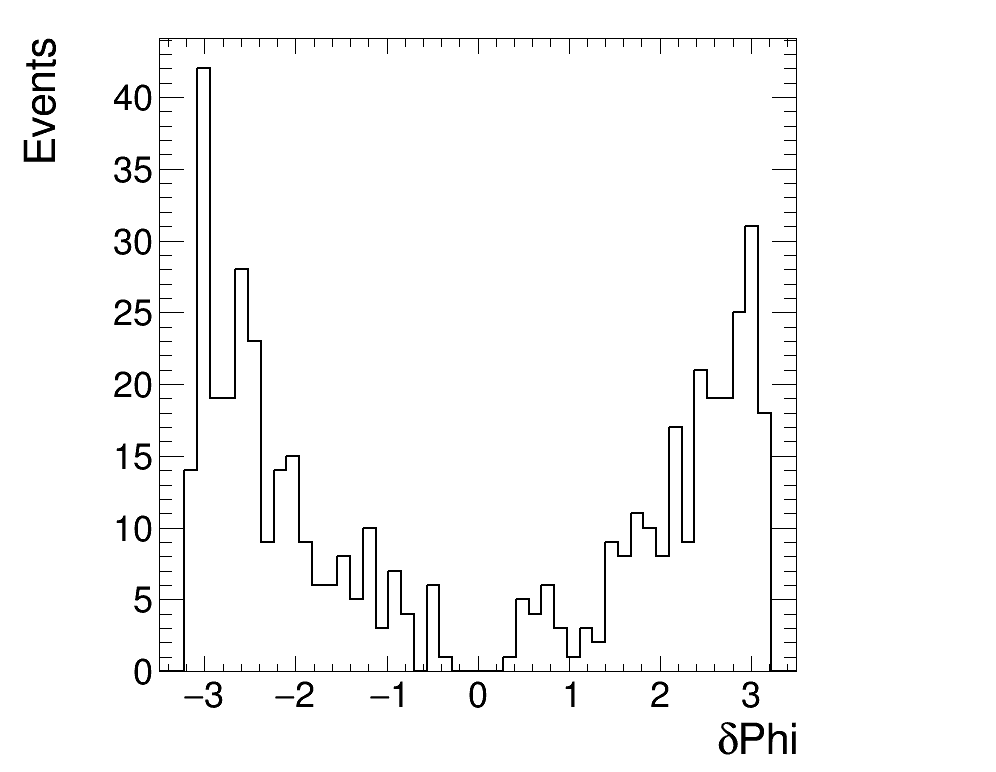

In [23]:
# Plotting ncsc
start_t = time.time()
c = rt.TCanvas('c','c', 1000, 800)
h = {}
leg = rt.TLegend(0.5,0.7,0.8,0.9)
leg.SetBorderSize(0)
# plot_var = [cscRechitClusterSize1, deltaPhi_cluster]
# axis = ['N_{rechits}','#Delta#phi',]
# name = ['nhits','dphi']
# bins = [[25,50,500],[25,1.8,3.2]]

k = "signal_sig_inclusive"
# h = create_TH2D(np.column_stack(( np.array(cscRechitClusterEta[k]), np.array(cscRechitClusterPhi[k]))),\
#                axis_title = ['CSC cluster #eta','CSC cluster #phi','Events'], binning=[100,-3,3,100,-3.2,3.2])
# h = create_TH2D(np.column_stack(( np.array(dtRechitClusterEta[k]), np.array(dtRechitClusterPhi[k]))),\
#                axis_title = ['DT cluster #eta','DT cluster #phi','Events'], binning=[100,-3,3,100,-3.2,3.2])
# h = create_TH1D( np.array(deltaPhi_cluster['oot_dataall_highMET']), \
#                axis_title = ['DT cluster #phi','Events'], binning=[100,-3.2,3.2])
# h = create_TH1D( np.array(cscRechitClusterSize['oot_dataall_highMET']), \
#                axis_title = ['DT cluster size','Events'], binning=[100,50,1000])
cond = dtRechitClusterSize[k]<100
cond = cond & (met[k]>50)
print(k, np.sum(weight[k][cond]))
# cond = np.abs(deltaPhi_cluster[k])<2.5
# cond_new = (np.abs(cscRechitClusterMet_dPhi[k]) < 2) & (np.abs(dtRechitClusterMet_dPhi[k]) < 2)
print(np.count_nonzero(cond)/len(cond))

# h = create_TH2D(np.column_stack(( np.array(dtRechitClusterSize[k][cond]), np.abs(np.array(deltaPhi_cluster[k][cond])))),\
#                axis_title = ['cluster size', 'cluster phi','Events'], binning=[100,50,500,100,0,3.2])
# h = create_TH2D(np.column_stack(( np.array(dtRechitClusterEta[k][cond]), np.array(dtRechitClusterPhi[k][cond]))),\
#                axis_title = ['cluster eta', 'cluster phi','Events'], binning=[30,-1.5,1.5,30,-4,4])

# h = create_TH2D(np.column_stack(( np.array(cscRechitClusterEta[k][cond]), np.array(cscRechitClusterPhi[k][cond]))),\
#                axis_title = ['cluster eta', 'cluster phi','Events'], binning=[30,-2.5,2.5,30,-4,4])
# h = create_TH2D(np.column_stack(( np.abs(np.array(deltaPhi_cluster[k][cond])), np.array(met[k][cond]))),\
#                axis_title = ['deltaphi','met','Events'], binning=[100,0,3.2,100,0,500])
# cond = cond & (np.abs(dtRechitClusterEta[k])<0.1)
# cond = cond & (np.abs(dtRechitClusterPhi[k]-2)<0.1)
# # h = create_TH1D( np.array(dtRechitClusterEta[k][cond]), \
# #                axis_title = ['DT cluster #eta','Events'], binning=[50,-1.5,1.5])

# h = create_TH1D( np.array(dtRechitClusterPhi[k][cond]), \
#                axis_title = ['DT cluster #phi','Events'], binning=[50,-3.5,3.5])
h = create_TH1D( np.array(deltaPhi_cluster[k][cond]), \
               axis_title = ['#deltaPhi','Events'], binning=[50,-3.5,3.5])

# h = create_TH1D( np.array(runNum[k][cond]), \
#                axis_title = ['DT cluster #phi','Events'], binning=[100,380000, 385713])
h.Draw('colz')

# print(np.min(runNum[k]),np.max(runNum[k]))
# h = create_TH1D( np.array(runNum[k][cscRechitClusterSize[k]>160]), axis_title = ['run number','Events'], binning=[100,360000,371000])
# h.Draw()
# h[k].SetLineColor(std_color_list[i])
# leg.AddEntry(h[k],k.replace('all',''))

c.SetRightMargin(0.2)
# c.SetLogy()
c.Draw()

# c.SaveAs("/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/"+name[plot_index]+".png")
# c.SaveAs("/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/"+name[plot_index]+".pdf")
# c.SaveAs("/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/"+name[plot_index]+".C")






## Create datacard with OOT data for optimization

In [15]:
# if MET_THRESHOLD == 100: datacard_version = "v11"
# elif MET_THRESHOLD == 75:  datacard_version = "v12"
# elif MET_THRESHOLD == 80:  datacard_version = "v13"
# elif MET_THRESHOLD == 90:  datacard_version = "v14"


# if MET_THRESHOLD == 50: datacard_version = 'v23'
# elif MET_THRESHOLD == 100:datacard_version = 'v24'
# elif MET_THRESHOLD == 75:datacard_version = 'v25'
# datacard_version = "v24"

#for PUPPI MET and applied jet veto and everything:
# if categories == ['inclusive']:datacard_version = 'v26'
# elif MET_THRESHOLD == 50: datacard_version = 'v27'
# elif MET_THRESHOLD == 30: datacard_version = 'v28'
datacard_version = "v41"

print(categories)
print(datacard_version)

['lowMET', 'highMET']
v41


In [16]:

for cat in categories:
    # if "high" in cat:continue
    data_key = f'signal_dataall_{cat}'
    signal_key = f'signal_sig_{cat}'
    a, b, c, d, pred = {}, {}, {}, {}, {}

    outDataCardsDir=f"/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3HMT/dtcsc/OOT_opt/{datacard_version}/"
    tree_dir = outDataCardsDir.replace("datacards","limitTrees")
    os.system(f"mkdir -p {outDataCardsDir}")
    os.system(f"mkdir -p {tree_dir}")

    modelName="ggH_HToSSTobbbb_MH-125_MS-15_CTau1000"

    sig_unc = {'test':[0.2]*4}
    sig_unc_name = ['test']
    signal_region = 'a'
    prefix = f'dtcsc_{cat}_'

    h = {
    signal_key: rt.TH2D("","",12,80,200, 12,2.,3.2),
    data_key: rt.TH2D("","",12,80,200, 12,2.,3.2),
    }
    if "low" in cat:csc_scan = list(np.arange(100,200,10))
    elif "high" in cat: csc_scan = list(np.arange(50,150,10))
    else: csc_scan = list(np.arange(100,200,10))

    for cscnhit_cut in csc_scan:
        print(cscnhit_cut)
        for dtnhit_cut in np.arange(80,250,10):
            for dphi_cut in np.arange(0.5, 3.2, 0.1):
                k = signal_key
                for k in [data_key, signal_key]:

                    if k == data_key: TF = len(dtRechitClusterSize[data_key.replace("oot","signal")][cscRechitClusterSize[data_key.replace("oot","signal")]>cscnhit_cut])\
                    /len(dtRechitClusterSize[data_key][cscRechitClusterSize[data_key]>cscnhit_cut])
                    else: TF = 1
                    cond = cscRechitClusterSize[k]>cscnhit_cut
                    
                    a[k] = np.sum(weight[k][cond & (dtRechitClusterSize[k]>=dtnhit_cut) &  (np.abs(deltaPhi_cluster[k])>=dphi_cut)]) * TF
                    b[k] = np.sum(weight[k][cond & (dtRechitClusterSize[k]>=dtnhit_cut) &  (np.abs(deltaPhi_cluster[k])<dphi_cut)]) * TF
                    c[k] = np.sum(weight[k][cond & (dtRechitClusterSize[k]<dtnhit_cut) &  (np.abs(deltaPhi_cluster[k])<dphi_cut)]) * TF
                    d[k] = np.sum(weight[k][cond & (dtRechitClusterSize[k]<dtnhit_cut) &  (np.abs(deltaPhi_cluster[k])>=dphi_cut)]) * TF
                    # if k == data_key: print(cscnhit_cut, dtnhit_cut, dphi_cut, TF, a[k],b[k],c[k],d[k])
                    if c[k] == 0: pred[k] = 999
                    else: pred[k] = b[k]*d[k]/c[k]
                    if k == data_key:
                        if b[k] < 1 or c[k] < 1 or d[k] < 1:continue
                        unc_pred = (TF/c[k] + TF/b[k] + TF/d[k])**0.5*pred[k]
                        # print(k,unc_pred,pred[k],a[k],b[k],c[k],d[k])
                if b[data_key] < 0.2 or c[data_key] < 0.2 or d[data_key] < 0.2:continue
                # print(nhit_cut, dphi_cut, a[signal_key], pred[data_key], a[signal_key]/pred[data_key], unc_pred, pred[data_key])


                xbin = h[data_key].GetXaxis().FindBin(dtnhit_cut)
                ybin = h[data_key].GetYaxis().FindBin(dphi_cut)
                h[data_key].SetBinContent(xbin,ybin,pred[data_key])
                h[signal_key].SetBinContent(xbin,ybin,a[signal_key])

                card_name = f'cscnhits{cscnhit_cut}_dtnhits{dtnhit_cut}_dphi'+str(round(dphi_cut,1)).replace(".","p") + f'_{cat}'

                ## create datacards ##
                make_datacard_2tag(
                outDataCardsDir,
                card_name,
                {'ggH':[a[signal_key],b[signal_key],c[signal_key],d[signal_key]]}, #signal rate
                a[signal_key], 
                [pred[data_key],b[data_key],c[data_key],d[data_key]], #bkg rate
                [a[data_key],b[data_key],c[data_key],d[data_key]], #observation
                [unc_pred/pred[data_key]], 
                ['syst'], 
                sig_unc, 
                signal_region, 
                prefix
                )

                # print(card_name, a[signal_key],pred[data_key])
            # break

100
110
120
130
140
150
160
170
180
190
50
60
70
80
90
100
110
120
130
140


# plot signal/bkg

Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/OOT_opt/signal_sig_lowMET_dtcsc.png has been created
Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/OOT_opt/signal_sig_lowMET_dtcsc.pdf has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/OOT_opt/signal_sig_lowMET_dtcsc.C has been generated


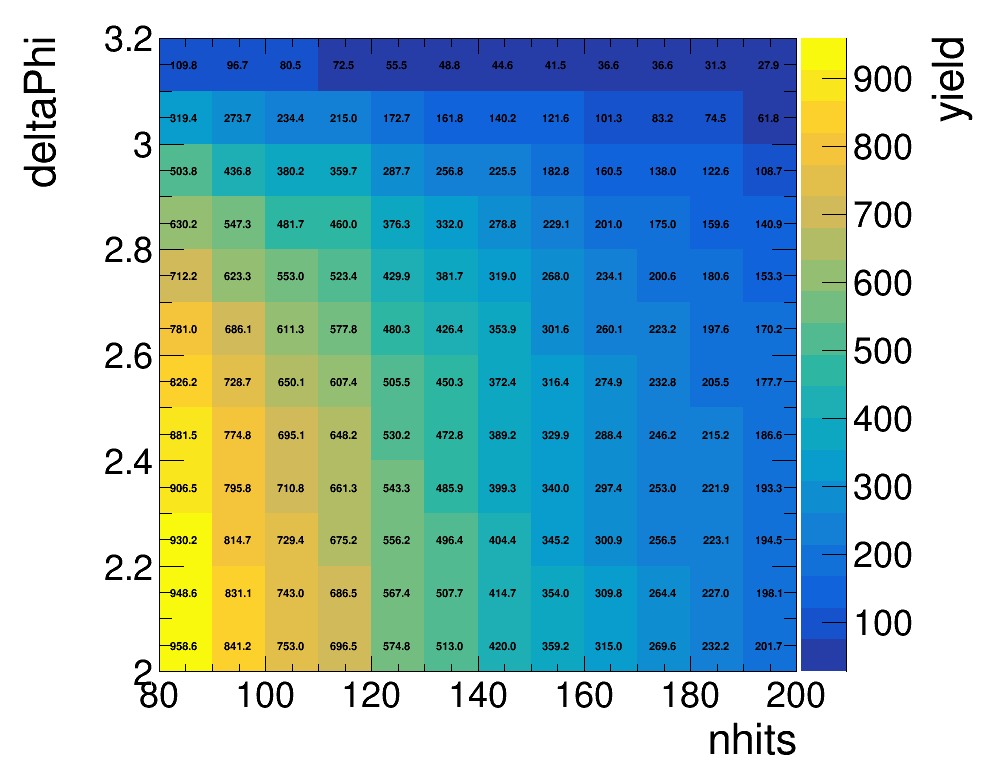

In [15]:
rt.gStyle.SetPaintTextFormat("1.1f");
c = rt.TCanvas('c','c', 1000, 800)

k = signal_key
# k = data_key
h[k].GetXaxis().SetTitle("nhits")
h[k].GetYaxis().SetTitle("deltaPhi")
h[k].GetZaxis().SetTitle("yield")
h[k].GetZaxis().SetTitleOffset(1.1)

h[k].SetMarkerSize(0.8)

h[k].Draw("colz text")
c.SetRightMargin(0.2)
c.Draw()

c.SaveAs("/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/OOT_opt/"+k+"_dtcsc.png")
c.SaveAs("/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/OOT_opt/"+k+"_dtcsc.pdf")
c.SaveAs("/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/OOT_opt/"+k+"_dtcsc.C")


## Plot combine result

In [4]:
categories = ['lowMET','highMET']
# categories = ['inclusive']
datacard_version = "v41"
outDataCardsDir=f"/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3HMT/dtcsc/OOT_opt/{datacard_version}/"
tree_dir = outDataCardsDir.replace("datacards","limitTrees")


1.0999999999999999 7937.44580078125
1.1999999999999997 7934.53076171875
1.2999999999999998 7926.595703125
1.4 7923.580078125
1.4999999999999998 7913.68408203125
1.5999999999999996 7906.04345703125
1.6999999999999997 7887.5537109375
1.7999999999999998 7867.771484375
1.8999999999999997 7836.02734375
1.9999999999999996 7783.8291015625
2.0999999999999996 7717.240234375
2.1999999999999997 7637.09765625
2.3 7499.4296875
2.3999999999999995 7311.4130859375
2.4999999999999996 7015.68310546875
2.5999999999999996 6601.6748046875
2.6999999999999993 6015.2138671875
2.7999999999999994 5241.5732421875
2.8999999999999995 4132.3369140625
2.9999999999999996 2710.0205078125
3.0999999999999996 812.919189453125
1.0999999999999999 7840.6005859375
1.1999999999999997 7837.685546875
1.2999999999999998 7829.7509765625
1.4 7826.734375
1.4999999999999998 7816.8388671875
1.5999999999999996 7809.1982421875
1.6999999999999997 7790.708984375
1.7999999999999998 7770.92626953125
1.8999999999999997 7739.517578125
1.9999

Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/OOT_opt/v41/limit_dtcsc_cscnhit100_lowMET.png has been created
Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/OOT_opt/v41/limit_dtcsc_cscnhit100_lowMET.pdf has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/OOT_opt/v41/limit_dtcsc_cscnhit100_lowMET.C has been generated
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/OOT_opt/v41/limit_dtcsc_cscnhit110_lowMET.png has been created
Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/OOT_opt/v41/limit_dtcsc_cscnhit110_lowMET.pdf has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af

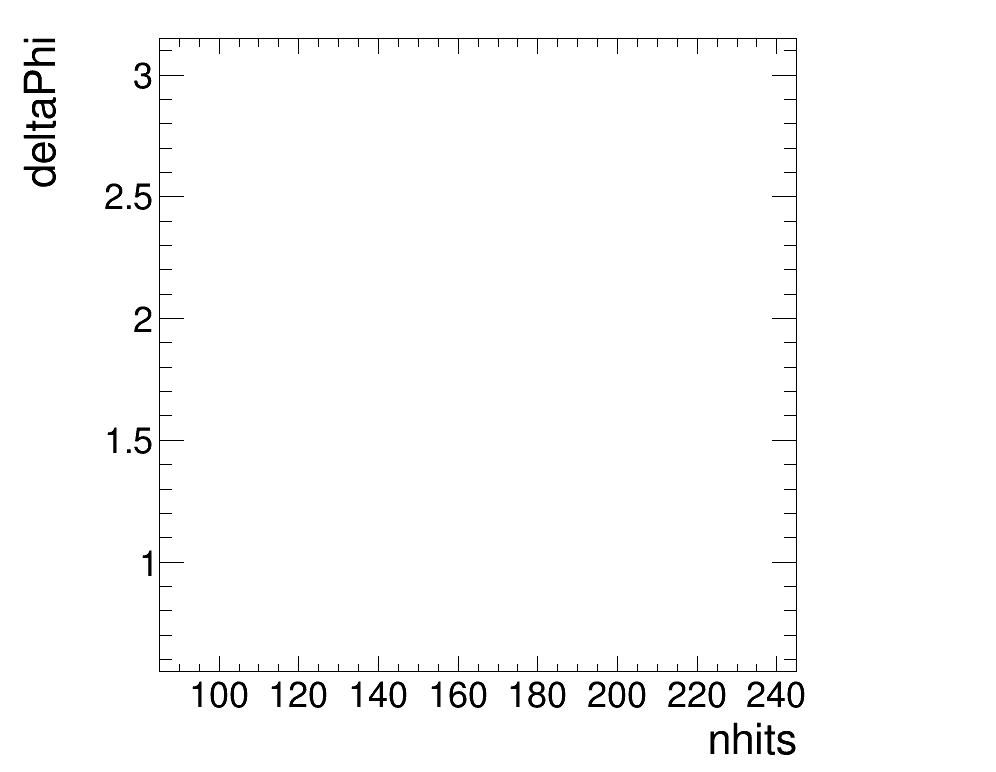

In [5]:
rt.gStyle.SetPaintTextFormat("1.4f");

c = rt.TCanvas('c','c', 1000, 800)
# h_opt = rt.TH2D("","",22,80,300, 22,1.0,3.2)
plot_dir = f"/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/OOT_opt/{datacard_version}"
os.makedirs(plot_dir, exist_ok=True)
for cat in categories:
    # if not "2" in cat:continue
    if "low" in cat:csc_scan = list(np.arange(100,200,10))
    else: csc_scan = list(np.arange(50,200,10))
    # csc_scan = [150]
    for cscnhit_cut in csc_scan:
        dtnhit_range = list(np.arange(80,250,10))
        dphi_range = list(np.arange(0.5, 3.2, 0.1))
        xwidth = 1.0* (dtnhit_range[-1]-dtnhit_range[0])/(len(dtnhit_range)-1)
        ywidth = 1.0* (dphi_range[-1]-dphi_range[0])/(len(dphi_range)-1)
        h_opt = rt.TH2D("","",len(dtnhit_range)-1,dtnhit_range[0]+xwidth/2,dtnhit_range[-1]+xwidth/2, \
                        len(dphi_range)-1,dphi_range[0]+ywidth/2,dphi_range[-1]+ywidth/2)
        for dtnhit_cut in dtnhit_range:
            for dphi_cut in dphi_range:

                ###### open datacard and limit ######
                card_name = f"cscnhits{cscnhit_cut}_dtnhits{dtnhit_cut}_dphi"+str(round(dphi_cut,1)).replace(".","p") + f'_{cat}'
                if not os.path.isfile(f"{outDataCardsDir}/{card_name}.txt"):
                    # print(f"{outDataCardsDir}/{card_name}.txt")
                    continue
                signal_norm = readNorm(f"{outDataCardsDir}/{card_name}.txt")
                if dtnhit_cut == 130:print(dphi_cut, signal_norm)

                tree_name = f"higgsCombine.{card_name}.AsymptoticLimits.mH120.root"
                limitTree = tree_dir + '/' + tree_name
                if not os.path.isfile(limitTree):
                    continue
                if len(uproot.open(limitTree).keys()) == 2:
                        T = uproot.open(limitTree)['limit']                
                        if len(np.array(T['limit'].array())>0):limit = np.array(T['limit'].array())/round(signal_norm,8)


                xbin = h_opt.GetXaxis().FindBin(dtnhit_cut)
                ybin = h_opt.GetYaxis().FindBin(dphi_cut)
                h_opt.SetBinContent(xbin,ybin,limit[2])
                # if limit[2]<0.008: print(nhit_cut, dphi_cut, limit[2], h[data_key].GetBinContent(xbin,ybin), h[signal_key].GetBinContent(xbin,ybin))

        h_opt.SetMarkerSize(0.8)
        h_opt.GetXaxis().SetTitle("nhits")
        h_opt.GetYaxis().SetTitle("deltaPhi")
        h_opt.GetZaxis().SetTitle("Limit on BR")
        h_opt.GetZaxis().SetTitleOffset(1.2)
        h_opt.Draw("colz text")
        c.SetRightMargin(0.2)
        c.Draw()

        c.SaveAs(f"{plot_dir}/limit_dtcsc_cscnhit{cscnhit_cut}_{cat}.png")
        c.SaveAs(f"{plot_dir}/limit_dtcsc_cscnhit{cscnhit_cut}_{cat}.pdf")
        c.SaveAs(f"{plot_dir}/limit_dtcsc_cscnhit{cscnhit_cut}_{cat}.C")
